# SPARC4 - AU Mic c - noite 2026-07-31

Versao simples, cinco celulas:

1. **configuracao** - noite, abertura, comparacoes, efemeride e parametros de AU Mic c
2. **fotometria** - alvo / soma das comparacoes, BJD_UTC -> BJD_TDB, corte de flares, binning
3. **previsao** - onde a efemeride poe o transito e quanto dele a noite cobre
4. **ajuste** - modelo batman + linha de base (reta + massa de ar), resolvidos juntos
5. **figura** e gravacao em `resultados_transitos/`

Se a efemeride nao puser transito nesta janela, a celula 3 avisa e o ajuste
passa a varrer a noite atras do melhor instante (`MODO = "busca"`).
Sabendo o instante do evento, basta preencher `TC_MANUAL` na celula 1.


In [1]:
# ═══ SPARC4 · AU Mic c · trânsito parcial · 2026-07-31 ══════════════════════
# Versão simples: fotometria diferencial -> linha de base -> modelo batman.
# Célula 1: tudo que se ajusta fica aqui.
import os

BASE   = r"C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data"
NIGHT  = "20260731"
OUTDIR = os.path.join(BASE, "resultados_transitos")

NIGHT_DIR   = os.path.join(BASE, "data", NIGHT)
NIGHT_LABEL = f"{NIGHT[:4]}-{NIGHT[4:6]}-{NIGHT[6:]}"
os.makedirs(OUTDIR, exist_ok=True)

# ── fotometria ───────────────────────────────────────────────────────────────
CHANNELS = [1, 2, 3, 4]
BANDS    = {1: "g", 2: "r", 3: "i", 4: "z"}
BEAM     = "S+N"        # soma dos feixes: cancela a modulação da lâmina
APER     = 8            # raio da abertura, em pixels
NCOMPS   = 3            # nº de comparações (as mais brilhantes depois do alvo)
COMPS    = {}           # p.ex. {1: [1, 3, 2]} força as comparações de um canal
BIN_MIN  = 5.0          # binning, em minutos
NSIG_FLARE = 3.0        # corta excursões positivas (flares) acima deste nível

# ── planeta: AU Mic c ────────────────────────────────────────────────────────
# CONFIRA estes números: são os da literatura (Martioli+2021). Com eles, o
# trânsito mais próximo NÃO cai nesta noite — a célula 3 diz exatamente onde
# cai. Se você tem outra efeméride, troque aqui; se quer analisar um evento
# num instante conhecido, use TC_MANUAL.
T0_TDB  = 2458342.2240   # BJD_TDB do trânsito de referência
T0_ERR  = 0.0012         # d
PER     = 18.859019      # d
PER_ERR = 0.000016       # d

RP_RS  = 0.0396          # Rp/R* (Rp = 3.24 R_terra, R* = 0.75 R_sol)
A_RS   = 32.5            # a/R*
INC    = 89.5            # graus
ECC, W = 0.0, 90.0

# escurecimento de bordo quadrático por banda (Teff 3700 K, logg 4.5) —
# valores aproximados de tabelas de Claret para o sistema SDSS
LDC = {"g": [0.62, 0.28], "r": [0.55, 0.32],
       "i": [0.40, 0.33], "z": [0.30, 0.32]}

# ── o que fazer com o instante do trânsito ───────────────────────────────────
TC_MANUAL = None    # BJD_TDB do centro, se você souber; None = usa a efeméride
MODO      = "auto"  # "auto"    -> efeméride (ou TC_MANUAL), com busca fina em ±DT_MAX
                    # "busca"   -> varre a noite inteira procurando o melhor Tc
DT_MAX    = 30.0    # busca fina, em minutos

# ── linha de base ────────────────────────────────────────────────────────────
BASE_ORD  = 1       # ordem do polinômio no tempo (1 = reta)
USA_MASSA = True    # inclui termo linear em (massa de ar - 1)

print(f"noite {NIGHT_LABEL}  ->  {NIGHT_DIR}")
print(f"AU Mic c: P = {PER} d | Rp/R* = {RP_RS} -> profundidade "
      f"~ {RP_RS**2*1e3:.2f} ppt (sem escurecimento de bordo)")



noite 2026-07-31  ->  C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data\data\20260731
AU Mic c: P = 18.859019 d | Rp/R* = 0.0396 -> profundidade ~ 1.57 ppt (sem escurecimento de bordo)


In [2]:
# ═══ 2 · fotometria diferencial simples ═════════════════════════════════════
# alvo / soma das comparações, tempo em BJD_TDB, flares cortados, binado.
import glob, re
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from astropy.io import fits
from astropy.time import Time
from astropy.coordinates import EarthLocation, SkyCoord, AltAz
from scipy.ndimage import median_filter
import astropy.units as u

CORES = {"g": "#3b6ea5", "r": "#3f8f4f", "i": "#c06a2a", "z": "#8b3a5a"}

def le_curva(ch):
    """Lê o produto do canal e devolve t(BJD_TDB), mag(nsrc,nt), emag, índices."""
    arq = sorted(glob.glob(os.path.join(NIGHT_DIR, f"*_s4c{ch}_*_{BEAM}_lc.fits")))[0]
    with fits.open(arq) as h:
        ext = [e.name for e in h if re.search(rf"AP0*{APER}$", e.name or "")][0]
        d, hdr0 = h[ext].data, h[0].header
        src  = np.asarray(d["SRCINDEX"]).astype(int)
        tempo = np.asarray(d["TIME"], float)
        mag, emag = np.asarray(d["MAG"], float), np.asarray(d["EMAG"], float)
        flag = np.asarray(d["FLAG"]) if "FLAG" in d.columns.names else None
    idx, t = np.unique(src), np.unique(tempo)
    lin, col = np.searchsorted(idx, src), np.searchsorted(t, tempo)
    M = np.full((idx.size, t.size), np.nan);  E = np.full_like(M, np.nan)
    M[lin, col], E[lin, col] = mag, emag
    if flag is not None:
        ruim = np.full(M.shape, False);  ruim[lin, col] = np.asarray(flag) != 0
        M[ruim] = np.nan
    return arq, hdr0, t, idx, M, E

def massa_de_ar(t_utc, hdr0):
    local = EarthLocation(lat=hdr0["OBSLAT"] * u.deg, lon=hdr0["OBSLONG"] * u.deg,
                          height=hdr0["OBSALT"] * u.m)
    alvo  = SkyCoord(hdr0["RA"] * u.deg, hdr0["DEC"] * u.deg, frame="icrs")
    tempo = Time(t_utc, format="jd", scale="utc")
    return alvo.transform_to(AltAz(obstime=tempo, location=local)).secz.value

def binar(t, y, e, dt_min):
    k = np.floor((t - t.min()) / (dt_min / 1440)).astype(int)
    tb, yb, eb, nb = [], [], [], []
    for g in np.unique(k):
        m = k == g
        tb.append(t[m].mean());  yb.append(np.mean(y[m]))
        eb.append(np.std(y[m], ddof=1) / np.sqrt(m.sum()) if m.sum() > 1 else e[m][0])
        nb.append(int(m.sum()))
    return map(np.array, (tb, yb, eb, nb))

dados, linhas = {}, []
for ch in CHANNELS:
    arq, hdr0, t_utc, idx, M, E = le_curva(ch)

    # alvo = fonte mais brilhante; comparações = as NCOMPS seguintes
    ordem = idx[np.argsort(np.nanmedian(M, axis=1))]
    alvo  = int(ordem[0])
    comps = COMPS.get(ch, [int(i) for i in ordem[1:1 + NCOMPS]])
    ia = int(np.where(idx == alvo)[0][0])
    ic = [int(np.where(idx == c)[0][0]) for c in comps]

    # razão de fluxos alvo / soma das comparações
    with np.errstate(invalid="ignore", divide="ignore"):
        f_alvo = 10 ** (-0.4 * M[ia])
        f_comp = np.nansum(10 ** (-0.4 * M[ic]), axis=0)
        razao  = f_alvo / f_comp
        e_raz  = razao * 0.4 * np.log(10) * np.hypot(
            E[ia], np.sqrt(np.nansum((10 ** (-0.4 * M[ic]) * E[ic]) ** 2, axis=0)) /
            np.where(f_comp > 0, f_comp, np.nan))
    ok = np.isfinite(razao) & np.isfinite(e_raz)
    t_tdb = Time(t_utc, format="jd", scale="utc").tdb.jd     # BJD_UTC -> BJD_TDB
    t_tdb, razao, e_raz = t_tdb[ok], razao[ok] / np.nanmedian(razao[ok]), e_raz[ok]
    X = massa_de_ar(t_utc[ok], hdr0)

    # flares: tira o que sobe acima de NSIG_FLARE da mediana móvel de 10 min
    n_jan = max(int(round((10 / 1440) / np.median(np.diff(t_tdb)))) | 1, 3)
    resid = razao - median_filter(razao, size=n_jan, mode="nearest")
    sigma = 1.4826 * np.median(np.abs(resid - np.median(resid)))
    limpo = resid < NSIG_FLARE * sigma

    tb, fb, eb, nb = binar(t_tdb[limpo], razao[limpo], e_raz[limpo], BIN_MIN)
    fb = fb / np.median(fb)
    # erro realista do bin: o formal costuma subestimar, então usa-se o maior
    # entre ele e a dispersão entre bins vizinhos (ruído branco efetivo)
    eb = np.maximum(eb, np.std(np.diff(fb)) / np.sqrt(2))
    Xb = np.interp(tb, t_tdb, X)
    dados[ch] = dict(band=BANDS[ch], arq=os.path.basename(arq), alvo=alvo,
                     comps=comps, t=t_tdb, f=razao, X=X, limpo=limpo,
                     tb=tb, fb=fb, eb=eb, nb=nb, Xb=Xb)
    linhas.append(dict(banda=f"{BANDS[ch]}'", alvo=alvo, comps=str(comps),
                       n_fits=int(t_tdb.size), flares=int((~limpo).sum()),
                       n_bins=int(tb.size), erro_bin_ppt=np.mean(eb) * 1e3,
                       ruido_bin_ppt=np.std(np.diff(fb)) / np.sqrt(2) * 1e3))

TSTART = min(d["t"].min() for d in dados.values())
TSTOP  = max(d["t"].max() for d in dados.values())
display(pd.DataFrame(linhas).set_index("banda").style.format(
    {"erro_bin_ppt": "{:.2f}", "ruido_bin_ppt": "{:.2f}"}))
print(f"janela: {TSTART:.6f} .. {TSTOP:.6f} BJD_TDB  ({(TSTOP-TSTART)*24:.2f} h)")
print(f"        {Time(TSTART, format='jd').isot} .. {Time(TSTOP, format='jd').isot} UTC")
print(f"bins de {BIN_MIN:.0f} min · AP{APER:03d} · feixe {BEAM}")



,alvo,comps,n_fits,flares,n_bins,erro_bin_ppt,ruido_bin_ppt
banda,,,,,,,
g',0,"[1, 3, 2]",10000,34,100,1.08,1.08
r',0,"[1, 2, 3]",21600,135,100,0.93,0.92
i',0,"[1, 2, 3]",21599,135,100,1.31,1.31
z',0,"[1, 2, 3]",21600,124,100,2.57,2.57


janela: 2461253.478943 .. 2461253.825039 BJD_TDB  (8.31 h)
        2026-07-31T23:29:40.647 .. 2026-08-01T07:48:03.347 UTC
bins de 5 min · AP008 · feixe S+N


In [4]:
# ═══ 3 · onde cai o trânsito? ═══════════════════════════════════════════════
import numpy as np
from astropy.time import Time

# duração do trânsito pela geometria
bimp = A_RS * np.cos(np.radians(INC))
T14  = PER / np.pi * np.arcsin(np.sqrt(max((1 + RP_RS) ** 2 - bimp ** 2, 0))
                               / (A_RS * np.sin(np.radians(INC))))

E_mid = (0.5 * (TSTART + TSTOP) - T0_TDB) / PER
print(f"AU Mic c: T14 = {T14*24:.2f} h | b = {bimp:.3f}")
print("trânsitos previstos mais próximos desta noite:")
for E in [int(np.floor(E_mid)), int(np.ceil(E_mid))]:
    tc = T0_TDB + E * PER
    dentro = TSTART <= tc <= TSTOP
    print(f"   E={E}: Tc = {tc:.5f} BJD_TDB  ({Time(tc, format='jd').isot} UTC)"
          f"   {'<-- DENTRO da janela' if dentro else ''}")

EPOCH = int(round(E_mid))
TC_EFEM = T0_TDB + EPOCH * PER
TC_ERR  = np.hypot(T0_ERR, EPOCH * PER_ERR)
sobrepoe = (TC_EFEM + T14 / 2 > TSTART) and (TC_EFEM - T14 / 2 < TSTOP)

if TC_MANUAL is not None:
    TC, origem = float(TC_MANUAL), "TC_MANUAL"
elif sobrepoe:
    TC, origem = TC_EFEM, "efeméride"
else:
    TC, origem = 0.5 * (TSTART + TSTOP), "centro da janela (só ponto de partida)"
    if MODO == "auto":
        MODO = "busca"
        print("\nA efeméride não põe trânsito nesta janela -> MODO = 'busca':\n"
              "o ajuste vai varrer a noite inteira procurando o melhor Tc.\n"
              "Se você tem a efeméride certa, corrija T0_TDB/PER na célula 1,\n"
              "ou informe o instante do evento em TC_MANUAL.")

ING, EGR = TC - T14 / 2, TC + T14 / 2
cob = (min(TSTOP, EGR) - max(TSTART, ING)) / T14
print(f"\nTc adotado = {TC:.5f} BJD_TDB   (origem: {origem})")
print(f"modo do ajuste = {MODO}")
print(f"cobertura em torno desse Tc: {cob*100:.0f} % de T14 "
      f"({'parcial' if cob < 0.99 else 'completo'})")



AU Mic c: T14 = 4.43 h | b = 0.284
trânsitos previstos mais próximos desta noite:
   E=154: Tc = 2461246.51293 BJD_TDB  (2026-07-25T00:18:36.806 UTC)   
   E=155: Tc = 2461265.37194 BJD_TDB  (2026-08-12T20:55:36.048 UTC)   

Tc adotado = 2461253.65199 BJD_TDB   (origem: centro da janela (só ponto de partida))
modo do ajuste = busca
cobertura em torno desse Tc: 100 % de T14 (completo)


In [5]:
# ═══ 4 · modelo de trânsito (batman) + linha de base ════════════════════════
# A profundidade entra como um fator de escala do modelo da literatura e é
# resolvida junto com a linha de base num único sistema linear; o instante Tc,
# que é o único parâmetro não-linear, é varrido numa grade.
import numpy as np, pandas as pd, batman

chs, bandas = sorted(dados), [dados[c]["band"] for c in sorted(dados)]

def modelo(t, tc, band, exp_min=BIN_MIN):
    p = batman.TransitParams()
    p.t0, p.per, p.rp, p.a, p.inc = tc, PER, RP_RS, A_RS, INC
    p.ecc, p.w, p.u, p.limb_dark = ECC, W, list(LDC[band]), "quadratic"
    m = batman.TransitModel(p, np.asarray(t, float), supersample_factor=7,
                            exp_time=exp_min / 1440)
    return m.light_curve(p)

# profundidade do modelo da literatura, por banda (com escurecimento de bordo)
_tf   = np.linspace(TC - T14, TC + T14, 2000)
PROF0 = {b: 1 - modelo(_tf, TC, b, 0.5).min() for b in bandas}

def perfil(t, tc, band):
    """0 fora do trânsito, PROF0 no centro."""
    return 1 - modelo(t, tc, band)

def base_design(ch):
    d  = dados[ch]
    tn = (d["tb"] - TC) * 24
    cols = [np.ones_like(tn)] + [tn ** k for k in range(1, BASE_ORD + 1)]
    if USA_MASSA:
        cols.append(d["Xb"] - 1)
    return np.column_stack(cols)

DES = {ch: base_design(ch) for ch in chs}
NB  = DES[chs[0]].shape[1]

def ajusta(tc, com_transito=True):
    """Resolve linha de base (+ escala da profundidade). -> chi2, par, cov, ndof"""
    n   = sum(dados[ch]["tb"].size for ch in chs)
    ncol = len(chs) * NB + (1 if com_transito else 0)
    G, y, w, i0 = np.zeros((n, ncol)), np.zeros(n), np.zeros(n), 0
    for j, ch in enumerate(chs):
        d = dados[ch];  k = d["tb"].size;  sl = slice(i0, i0 + k)
        G[sl, j * NB:(j + 1) * NB] = DES[ch]
        if com_transito:
            G[sl, -1] = -perfil(d["tb"], tc, d["band"])
        y[sl], w[sl] = d["fb"], 1 / d["eb"]
        i0 += k
    Gw, yw = G * w[:, None], y * w
    par, *_ = np.linalg.lstsq(Gw, yw, rcond=None)
    chi2 = float(np.sum((Gw @ par - yw) ** 2))
    return chi2, par, np.linalg.pinv(Gw.T @ Gw), n - ncol

# grade de Tc. No modo busca o centro pode cair FORA da janela (é assim que se
# acha um trânsito parcial no começo ou no fim da noite); exige-se apenas um
# mínimo de pontos dentro do trânsito.
MIN_DENTRO = 6          # nº mínimo de bins dentro do trânsito

if MODO == "busca":
    grade = np.arange(TSTART - T14 / 2, TSTOP + T14 / 2, 2.0 / 1440)
else:
    grade = TC + np.arange(-DT_MAX, DT_MAX + 0.01, 0.5) / 1440

def n_dentro(tc):
    d = dados[chs[0]]
    return int(np.sum(perfil(d["tb"], tc, bandas[0]) > 0.2 * PROF0[bandas[0]]))

vale  = np.array([n_dentro(tc) >= MIN_DENTRO for tc in grade])
chi2s = np.array([ajusta(tc)[0] if v else np.nan for tc, v in zip(grade, vale)])
if not np.any(vale):
    raise RuntimeError("nenhum Tc da grade tem pontos suficientes dentro do trânsito")
TC_FIT = float(grade[np.nanargmin(chi2s)])
deltas = np.array([ajusta(tc)[1][-1] if v else np.nan
                   for tc, v in zip(grade, vale)])

chi2, par, cov, ndof = ajusta(TC_FIT)
esc  = max(chi2 / ndof, 1.0)              # infla erros por causa do ruído correlacionado
delta, e_delta = par[-1], np.sqrt(abs(cov[-1, -1]) * esc)
chi2_sem = ajusta(TC_FIT, com_transito=False)[0]
dchi2 = (chi2_sem - chi2) / esc
nsig  = float(np.sign(delta) * np.sqrt(max(dchi2, 0)))

bases = {ch: DES[ch] @ par[j * NB:(j + 1) * NB] for j, ch in enumerate(chs)}
prof  = {b: delta * PROF0[b] for b in bandas}

print(f"Tc ajustado = {TC_FIT:.5f} BJD_TDB  "
      f"({Time(TC_FIT, format='jd').isot} UTC)")
if origem == "efeméride":
    print(f"O-C = {(TC_FIT - TC_EFEM)*1440:+.1f} min "
          f"(efeméride: ± {TC_ERR*1440:.1f} min)")
print(f"χ²/ndof = {chi2/ndof:.2f}   Δχ² = {dchi2:.1f}  ->  {nsig:+.1f}σ")
print(f"escala da profundidade: delta = {delta:.2f} ± {e_delta:.2f} "
      f"(1.00 = profundidade da literatura)\n")

tab = pd.DataFrame([{
    "banda": f"{b}'",
    "prof. esperada (ppt)": PROF0[b] * 1e3,
    "prof. medida (ppt)": prof[b] * 1e3,
    "sigma (ppt)": e_delta * PROF0[b] * 1e3,
    "rms resíduo (ppt)": np.std(dados[ch]["fb"] - bases[ch]
                                + delta * perfil(dados[ch]["tb"], TC_FIT, b)) * 1e3,
} for ch, b in zip(chs, bandas)]).set_index("banda")
display(tab.style.format("{:.2f}"))

if nsig > 3:
    veredito = "sinal com forma de trânsito"
elif nsig < -3:
    veredito = "CLAREAMENTO no lugar do trânsito (sistemática, não trânsito)"
else:
    veredito = "sem detecção significativa"
lim = 3 * e_delta * PROF0[bandas[0]] * 1e3
print(f"veredito: {veredito}")
print(f"referência — 3σ da profundidade em {bandas[0]}': {lim:.2f} ppt "
      f"(literatura: {PROF0[bandas[0]]*1e3:.2f} ppt)")

# onde caiu o melhor Tc em relação à noite observada
if TC_FIT < TSTART:
    onde = f"{(TSTART-TC_FIT)*24*60:.0f} min ANTES do início da noite (só o egresso)"
elif TC_FIT > TSTOP:
    onde = f"{(TC_FIT-TSTOP)*24*60:.0f} min DEPOIS do fim da noite (só o ingresso)"
else:
    onde = (f"dentro da janela, a {(TC_FIT-TSTART)*24:.1f} h do início "
            f"e {(TSTOP-TC_FIT)*24:.1f} h do fim")
print(f"posição do Tc ajustado: {onde}")

if MODO == "busca":
    print(f"\nCUIDADO com o Δχ² acima: no modo 'busca' o Tc fica livre na noite")
    print(f"inteira, e um trânsito de {T14*24:.1f} h ajustado numa janela de "
          f"{(TSTOP-TSTART)*24:.1f} h com")
    print("linha de base livre é degenerado com a variabilidade da estrela — o")
    print("número não é a significância de uma detecção (procurou-se em muitos")
    print("instantes). Serve como candidato: para confirmar, ponha a efeméride")
    print("certa em T0_TDB/PER, ou fixe o instante do evento em TC_MANUAL.")



Tc ajustado = 2461253.43100 BJD_TDB  (2026-07-31T22:20:38.369 UTC)
χ²/ndof = 3.30   Δχ² = 23.0  ->  +4.8σ
escala da profundidade: delta = 1.76 ± 0.37 (1.00 = profundidade da literatura)



,prof. esperada (ppt),prof. medida (ppt),sigma (ppt),rms resíduo (ppt)
banda,,,,
g',2.05,3.60,0.75,1.51
r',2.01,3.54,0.74,1.33
i',1.90,3.35,0.70,2.35
z',1.83,3.22,0.67,6.05


veredito: sinal com forma de trânsito
referência — 3σ da profundidade em g': 2.26 ppt (literatura: 2.05 ppt)
posição do Tc ajustado: 69 min ANTES do início da noite (só o egresso)

CUIDADO com o Δχ² acima: no modo 'busca' o Tc fica livre na noite
inteira, e um trânsito de 4.4 h ajustado numa janela de 8.3 h com
linha de base livre é degenerado com a variabilidade da estrela — o
número não é a significância de uma detecção (procurou-se em muitos
instantes). Serve como candidato: para confirmar, ponha a efeméride
certa em T0_TDB/PER, ou fixe o instante do evento em TC_MANUAL.


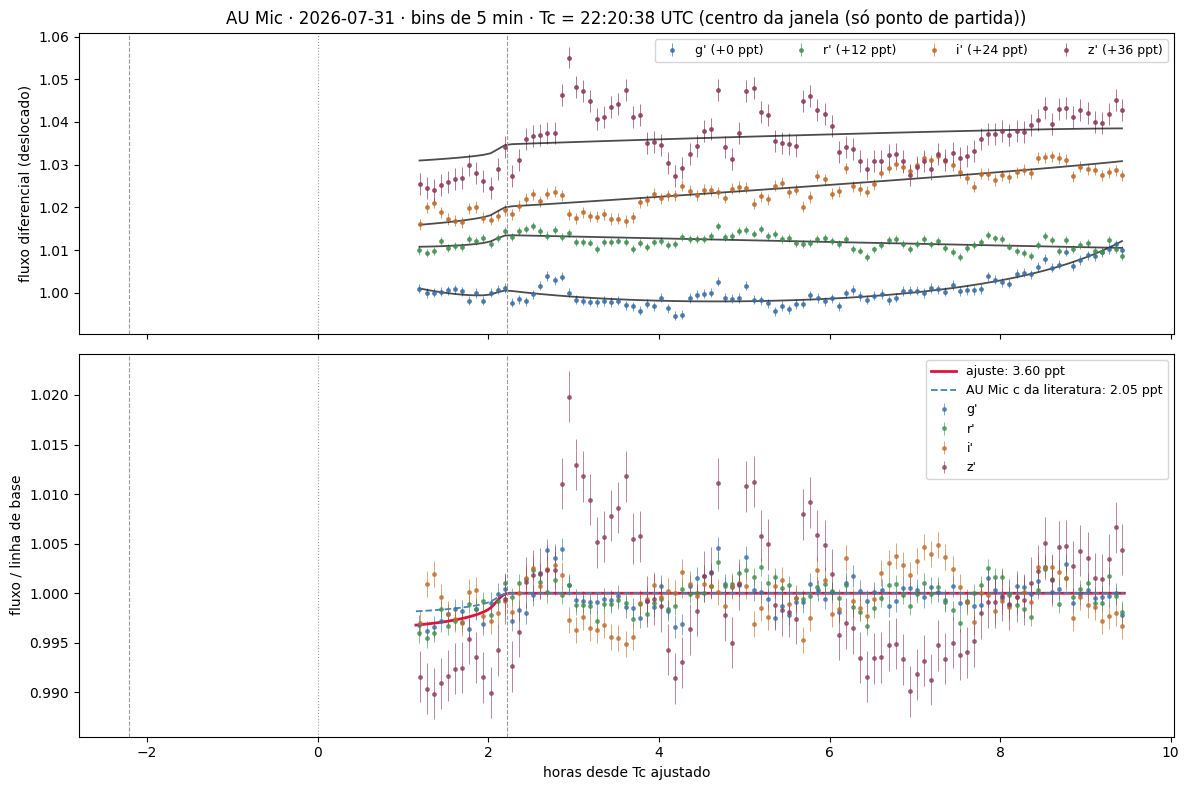

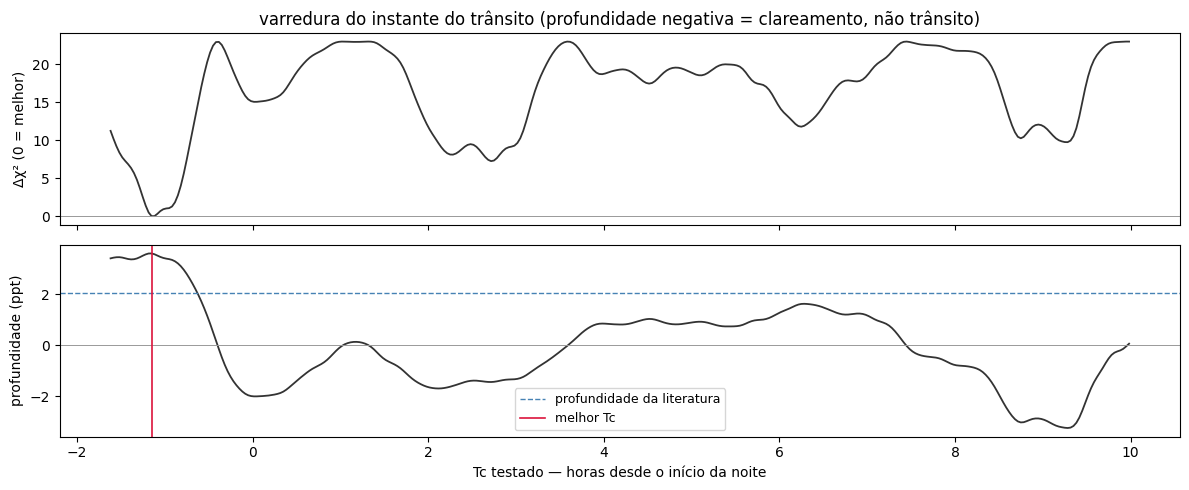

gravado: C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data\resultados_transitos\aumic_c_20260731_curvas_binadas.csv
         C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data\resultados_transitos\aumic_c_20260731_resumo.txt


In [6]:
# ═══ 5 · figura ═════════════════════════════════════════════════════════════
import numpy as np, matplotlib.pyplot as plt
from astropy.time import Time

tg = np.linspace(TSTART, TSTOP, 1200)
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                        gridspec_kw=dict(height_ratios=[1.1, 1.4]))

for j, ch in enumerate(chs):
    d, b = dados[ch], bandas[j]
    x = (d["tb"] - TC_FIT) * 24
    axs[0].errorbar(x, d["fb"] + j * 0.012, d["eb"], fmt=".", ms=5, lw=.6,
                    alpha=.8, color=CORES[b], label=f"{b}' (+{j*12:.0f} ppt)")
    axs[0].plot(x, bases[ch] - delta * perfil(d["tb"], TC_FIT, b) + j * 0.012,
                "-", lw=1.3, color="k", alpha=.7)
    axs[1].errorbar(x, d["fb"] / bases[ch], d["eb"], fmt=".", ms=5, lw=.6,
                    alpha=.7, color=CORES[b], label=f"{b}'")

axs[1].plot((tg - TC_FIT) * 24, 1 - delta * perfil(tg, TC_FIT, bandas[0]),
            "-", lw=2, color="crimson",
            label=f"ajuste: {prof[bandas[0]]*1e3:.2f} ppt")
axs[1].plot((tg - TC_FIT) * 24, 1 - perfil(tg, TC_FIT, bandas[0]),
            "--", lw=1.3, color="steelblue",
            label=f"AU Mic c da literatura: {PROF0[bandas[0]]*1e3:.2f} ppt")
for ax in axs:
    ax.axvline(-T14 / 2 * 24, color="0.6", lw=.8, ls="--")
    ax.axvline(+T14 / 2 * 24, color="0.6", lw=.8, ls="--")
    ax.axvline(0, color="0.6", lw=.8, ls=":")
axs[0].set_ylabel("fluxo diferencial (deslocado)")
axs[0].legend(ncol=4, fontsize=9)
axs[0].set_title(f"AU Mic · {NIGHT_LABEL} · bins de {BIN_MIN:.0f} min · "
                 f"Tc = {Time(TC_FIT, format='jd').isot[11:19]} UTC ({origem})")
axs[1].set_ylabel("fluxo / linha de base")
axs[1].set_xlabel("horas desde Tc ajustado")
axs[1].legend(fontsize=9)
plt.tight_layout();  plt.show()

# varredura: onde a noite aceitaria um trânsito, e de que profundidade
fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
hg = (grade - TSTART) * 24
ax[0].plot(hg, (np.nanmin(chi2s) - chi2s) / esc * -1, "-", lw=1.3, color="#333")
ax[0].axhline(0, color="0.6", lw=.7)
ax[0].set_ylabel("Δχ² (0 = melhor)")
ax[1].plot(hg, deltas * PROF0[bandas[0]] * 1e3, "-", lw=1.3, color="#333")
ax[1].axhline(0, color="0.6", lw=.7)
ax[1].axhline(PROF0[bandas[0]] * 1e3, color="steelblue", ls="--", lw=1,
              label="profundidade da literatura")
ax[1].axvline((TC_FIT - TSTART) * 24, color="crimson", lw=1.2, label="melhor Tc")
if origem == "efeméride":
    ax[1].axvline((TC_EFEM - TSTART) * 24, color="orange", lw=1.2, label="efeméride")
ax[1].set_ylabel("profundidade (ppt)")
ax[1].set_xlabel("Tc testado — horas desde o início da noite")
ax[1].legend(fontsize=9)
ax[0].set_title("varredura do instante do trânsito (profundidade negativa = "
                "clareamento, não trânsito)")
plt.tight_layout();  plt.show()

# guarda a curva e o resumo
pref = os.path.join(OUTDIR, f"aumic_c_{NIGHT}")
pd.concat([pd.DataFrame({"banda": dados[ch]["band"], "bjd_tdb": dados[ch]["tb"],
                         "fluxo": dados[ch]["fb"], "erro": dados[ch]["eb"],
                         "base": bases[ch], "n_fits": dados[ch]["nb"]})
           for ch in chs]).to_csv(pref + "_curvas_binadas.csv", index=False)
with open(pref + "_resumo.txt", "w", encoding="utf-8") as fh:
    fh.write(f"AU Mic c · {NIGHT_LABEL} · AP{APER:03d} · {BEAM} · bins {BIN_MIN:.0f} min\n")
    fh.write(f"janela {TSTART:.6f}..{TSTOP:.6f} BJD_TDB\n")
    fh.write(f"efeméride T0={T0_TDB} P={PER} -> Tc(E={EPOCH})={TC_EFEM:.5f}\n")
    fh.write(f"Tc adotado={TC:.5f} ({origem}) | modo={MODO}\n")
    fh.write(f"Tc ajustado={TC_FIT:.5f} | delta={delta:.3f}+-{e_delta:.3f} | "
             f"dchi2={dchi2:.1f} ({nsig:+.1f} sigma)\n")
    fh.write(f"veredito: {veredito}\n\n" + tab.to_string() + "\n")
print("gravado:", pref + "_curvas_binadas.csv")
print("        ", pref + "_resumo.txt")
